# Exercise_4.09_Tasks - Part 2.2

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [4]:
# create path
path='/home/haus/Exercise_4_Instacart_Basket_Analysis'

In [6]:
# Create an output for the folder Visualzations
output_dir = '/home/haus/Exercise_4_Instacart_Basket_Analysis/04_Analysis/Visualizations'

In [8]:
# Importing data-frame Customers
df_cop=pd.read_pickle(r'/home/haus/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data/cust_ords_prods_merged.pkl')

6 - Now that you have information about customers, you need to conduct some exploratory analysis of customer demographics to inform the targeted marketing campaigns. First, determine whether there’s a connection between age and family situation by creating a line chart exploring the connections between age and number of dependents:
In a markdown cell beneath your line chart, describe what the line chart shows.

Option 1: Using the Full DataFrame (df_cop)

In [12]:
# Aggregate: average number of dependents per age
age_dependents = df_cop.groupby('age')['n_dependants'].mean()

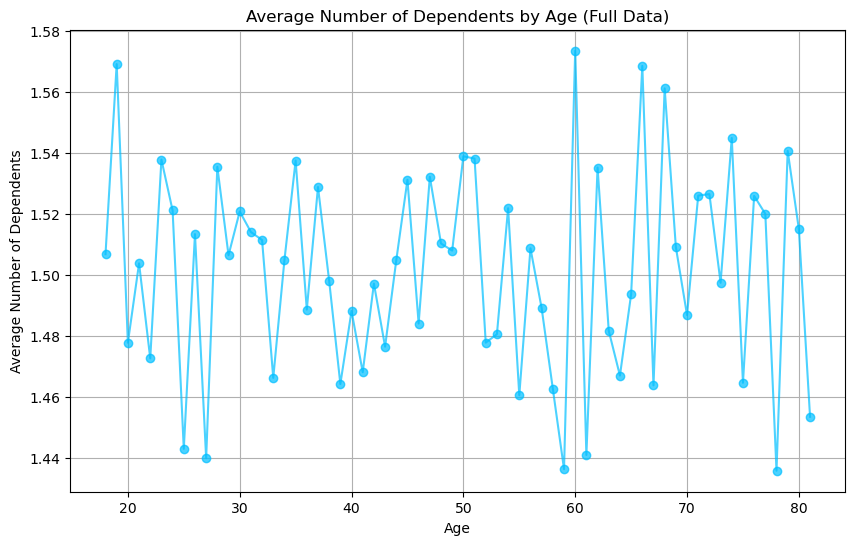

In [14]:
# Create line chart
fig1=plt.figure(figsize=(10, 6))
plt.plot(age_dependents.index, age_dependents.values, marker='o', color='deepskyblue', alpha=0.7)
plt.title('Average Number of Dependents by Age (Full Data)')
plt.xlabel('Age')
plt.ylabel('Average Number of Dependents')
plt.grid(True)

In [16]:
# Export to folder
fig1.savefig(os.path.join(output_dir, 'age_dependents_full.png'), bbox_inches='tight')

Option 2: Using the sample data-frame (80% of df_cop)

In [19]:
# 80/20 split: use 80% of the data as a sample
sample_df = df_cop.sample(frac=0.8, random_state=42)

In [21]:
# Aggregate: average number of dependents per age in the sample
age_dependents_sample = sample_df.groupby('age')['n_dependants'].mean()

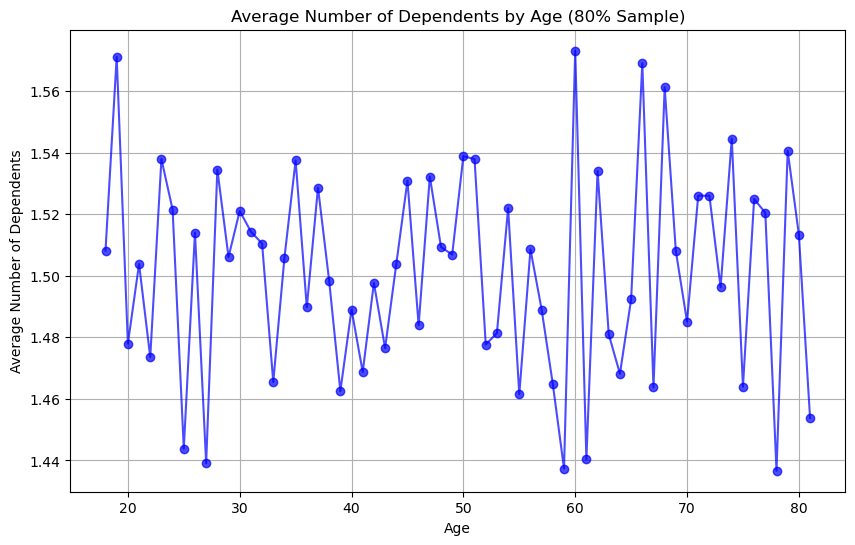

In [25]:
# Create line chart
fig2=plt.figure(figsize=(10, 6))
plt.plot(age_dependents_sample.index, age_dependents_sample.values, marker='o', color='blue', alpha=0.7)
plt.title('Average Number of Dependents by Age (80% Sample)')
plt.xlabel('Age')
plt.ylabel('Average Number of Dependents')
plt.grid(True)

In [27]:
# Export to folder
fig2.savefig(os.path.join(output_dir, 'dependents_by_age_sample.png'), dpi=300, bbox_inches='tight')

There are no clear patterns that would indicate a strong relationship between age and the number of dependents; for example, the line does not consistently go up or down as age increases

In [32]:
df_sample3=sample_df[['age', 'n_dependants']]

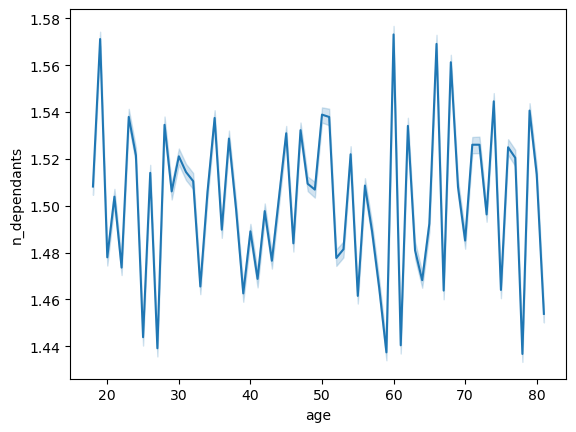

In [34]:
line_1 = sns.lineplot(data = df_sample3, x = 'age',y = 'n_dependants')

In [36]:
# Export chart line 
line_1.figure.savefig(os.path.join(output_dir, 'age_vs_n_dependants_sample.png'), dpi=300, bbox_inches='tight')

7 - You’ll also need to explore whether there’s a connection between age and spending power (income). To visualize this relationship, create a scatterplot using the sns.scatterplot() function. In a markdown cell beneath your scatterplot, describe what the scatterplot shows.

Option 1 - Full Data-frame.
Since the full dataset is extremely large (32 million rows), it will be necessary to implement proper data handling strategies to avoid the overflow errors.

In [41]:
# Configure matplotlib to handle large datasets
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # Increase chunk size for rendering

In [47]:
# Group by age and calculate mean income and count
age_income_data = df_cop.groupby('age')['income'].agg(['mean', 'count']).reset_index()

In [49]:
# Convert Int64Dtype to standard integer type to avoid the error
age_income_data['count'] = age_income_data['count'].astype(int)

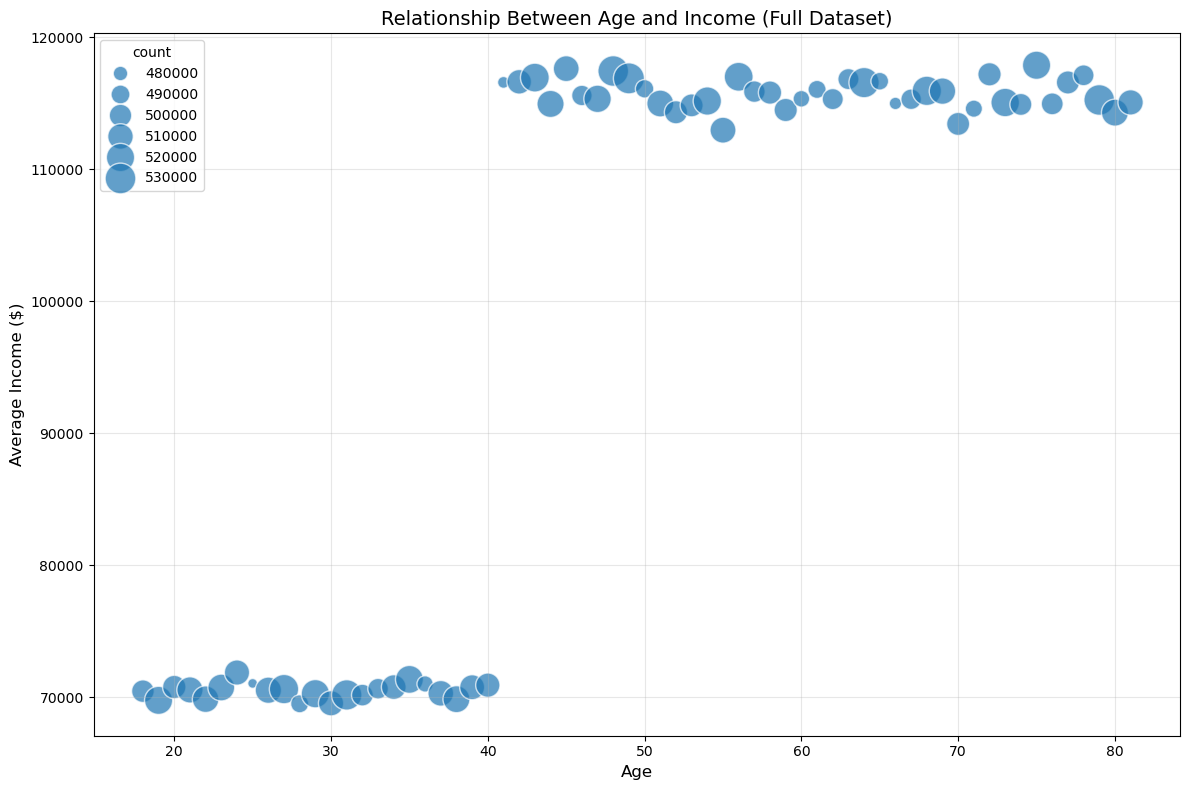

In [71]:
# Create scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=age_income_data, 
    x='age', 
    y='mean',
    size='count',
    sizes=(50, 500),
    alpha=0.7
)

plt.title('Relationship Between Age and Income (Full Dataset)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Income ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Save with proper settings to avoid blank images
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Scatterplot_age_income_full.png'), bbox_inches='tight', dpi=300)
plt.show()

Option 2 - Using the sample data-frame (80% of df_cop)

In [74]:
# Create 80% sample
sample_df2 = df_cop.sample(frac=0.8, random_state=42)

In [76]:
# Group by age and calculate mean income and count
sample_age_income = sample_df.groupby('age')['income'].agg(['mean', 'count']).reset_index()

In [78]:
# Convert Int64Dtype to standard integer type
sample_age_income['count'] = sample_age_income['count'].astype(int)

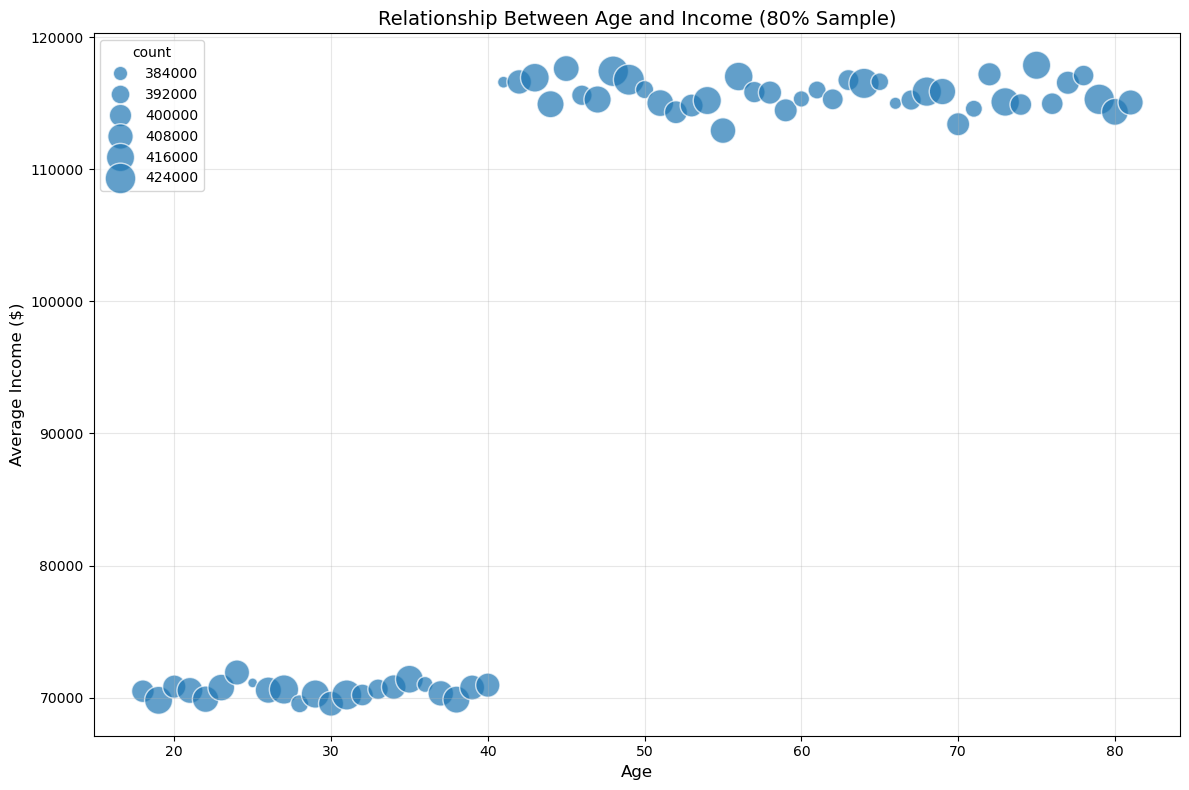

In [80]:
# Create scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=sample_age_income, 
    x='age', 
    y='mean',
    size='count',
    sizes=(50, 500),
    alpha=0.7
)

plt.title('Relationship Between Age and Income (80% Sample)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Income ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Save with proper settings
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Scatterplot_age_income_sample.png'), bbox_inches='tight', dpi=300)
plt.show()

In both cases there is a deep step at age 40, with an increase in income.

## Close Part2.2